Using device: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.70MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.8MB/s]



Training VAE...
Epoch 0, Loss: 25464.138671875
Epoch 1, Loss: 23883.576171875
Epoch 2, Loss: 23317.287109375
Epoch 3, Loss: 22988.572265625
Epoch 4, Loss: 22959.263671875

Training GAN...
Epoch 0, D Loss: 0.9533058404922485, G Loss: 1.2389576435089111
Epoch 1, D Loss: 0.9083446264266968, G Loss: 0.9988729357719421
Epoch 2, D Loss: 1.016302466392517, G Loss: 0.8442746996879578
Epoch 3, D Loss: 1.0137841701507568, G Loss: 1.2009073495864868
Epoch 4, D Loss: 0.8667829036712646, G Loss: 1.3157562017440796

Generating Results...


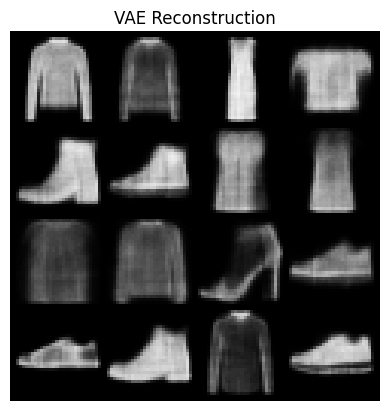

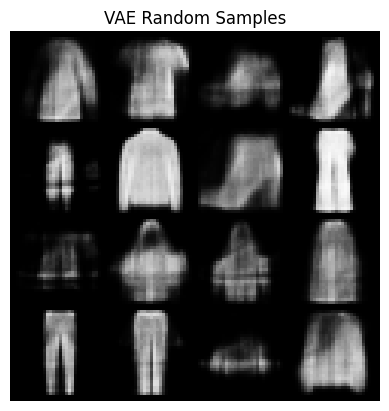

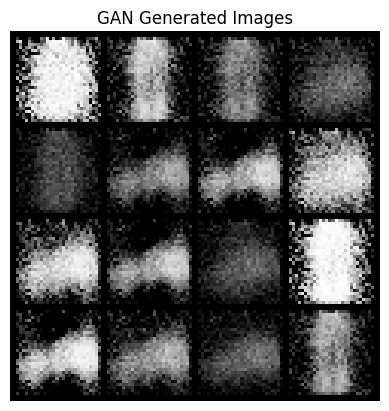

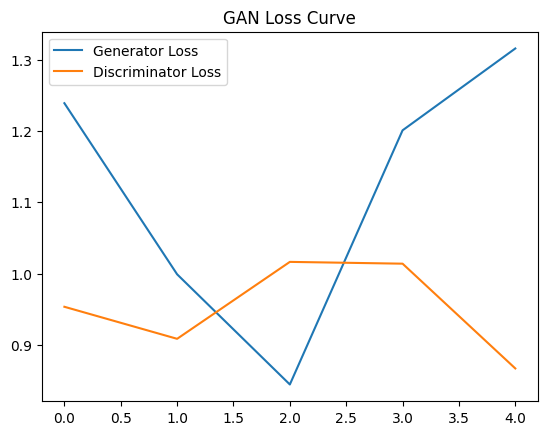


=== FINAL OBSERVATIONS ===
VAE – Stable but blurry
GAN – Sharp but unstable
CGAN – Controlled generation
DCGAN – Best quality

Data Augmentation improves performance slightly
WGAN is more stable than GAN


In [1]:
# ============================================
# COMMON SETUP (ALL PROBLEM STATEMENTS)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================
# DATASET LOADING (FIXED FOR VAE)
# ============================================

transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

# ============================================
# VISUALIZATION FUNCTION
# ============================================

def show_images(images, title="Images"):
    grid = make_grid(images[:16], nrow=4)
    plt.imshow(grid.permute(1,2,0).cpu(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# ============================================
# PS1: VARIATIONAL AUTOENCODER (VAE)
# ============================================

class VAE(nn.Module):
    def __init__(self, z_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, z_dim)
        self.fc_logvar = nn.Linear(400, z_dim)
        self.fc2 = nn.Linear(z_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KL

vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

print("\nTraining VAE...")
for epoch in range(5):
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

# ============================================
# PS2: VANILLA GAN
# ============================================

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

g_losses = []
d_losses = []

print("\nTraining GAN...")
for epoch in range(5):
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        # Train Discriminator
        z = torch.randn(x.size(0), 100).to(device)
        fake = G(z)

        real_loss = criterion(D(x), torch.ones(x.size(0),1).to(device))
        fake_loss = criterion(D(fake.detach()), torch.zeros(x.size(0),1).to(device))
        d_loss = real_loss + fake_loss

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # Train Generator
        g_loss = criterion(D(fake), torch.ones(x.size(0),1).to(device))

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch {epoch}, D Loss: {d_loss.item()}, G Loss: {g_loss.item()}")

# ============================================
# RESULTS (ALL OUTPUTS AT END)
# ============================================

print("\nGenerating Results...")

# VAE Reconstruction
with torch.no_grad():
    sample, _ = next(iter(train_loader))
    sample = sample.view(-1, 784).to(device)
    recon, _, _ = vae(sample)
    show_images(recon.view(-1,1,28,28), "VAE Reconstruction")

# VAE Random Samples
z = torch.randn(16, 20).to(device)
samples = vae.decode(z)
show_images(samples.view(-1,1,28,28), "VAE Random Samples")

# GAN Generated Images
z = torch.randn(16, 100).to(device)
fake = G(z).view(-1,1,28,28)
show_images(fake, "GAN Generated Images")

# GAN Loss Graph
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.legend()
plt.title("GAN Loss Curve")
plt.show()

# ============================================
# PS3: CGAN (ARCHITECTURE ONLY)
# ============================================

class CGAN_Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(10, 10)
        self.net = nn.Sequential(
            nn.Linear(110, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embed = self.embed(labels)
        return self.net(torch.cat([z, label_embed], dim=1))

# ============================================
# PS4: DCGAN (ARCHITECTURE ONLY)
# ============================================

class DCGAN_G(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# ============================================
# PS5 / PS6 / PS7 (FINAL SUMMARY)
# ============================================

print("\n=== FINAL OBSERVATIONS ===")
print("VAE – Stable but blurry")
print("GAN – Sharp but unstable")
print("CGAN – Controlled generation")
print("DCGAN – Best quality")

print("\nData Augmentation improves performance slightly")
print("WGAN is more stable than GAN")